### Imports

In [181]:
import io
from io import BytesIO
import fitz
import os
import base64
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import ollama

### Path

In [14]:
test_sample_1 = "/home/jerlshin/FieldOfInterest/My_Work/__PROJECTS__/TableExtraction/page_1.pdf"
test_sample_2 = "/home/jerlshin/FieldOfInterest/My_Work/__PROJECTS__/TableExtraction/page_2.pdf"

In [41]:
doc1 = fitz.open(test_sample_1)
doc2 = fitz.open(test_sample_2)

page1 = doc1[0]
page2 = doc2[0]

blocks1 = page1.get_text("blocks", sort=True)
blocks2 = page2.get_text("blocks", sort=True)

### Processing

In [ ]:
def extract_and_visualize_blocks(pdf_path, page_number=0, dpi=150):
    doc = fitz.open(pdf_path)

    temp_doc = fitz.open()                 # new pdf
    temp_doc.insert_pdf(doc, from_page=page_number, to_page=page_number)
    page = temp_doc[0]                     # copied page

    # text blocks
    blocks = page.get_text("blocks", sort=True)
    block_data = []

    for block in blocks:
        x0, y0, x1, y1, text, block_no, block_type = block

        width = round(x1 - x0, 2)
        height = round(y1 - y0, 2)
        area = round(width * height, 2)

        # leaving out the blocks which has area less than the threshold
        if area < 130:
            continue
        
        # minimum page size of the 
        rect = fitz.Rect(x0, y0, x1, y1)
        page.draw_rect(rect, color=(1, 0, 0), width=0.5)  # red box

        block_data.append([
            block_no, block_type, text.strip(),
            x0, y0, x1, y1, width, height, area
        ])

    df = pd.DataFrame(block_data, columns=[
        'block_no', 'block_type', 'text', 'x0', 'y0', 'x1', 'y1',
        'width', 'height', 'area'
    ])

    # Render the annotated page
    pix = page.get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png")))

    plt.figure(figsize=(12, 16))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    temp_doc.close()
    doc.close()

    return df

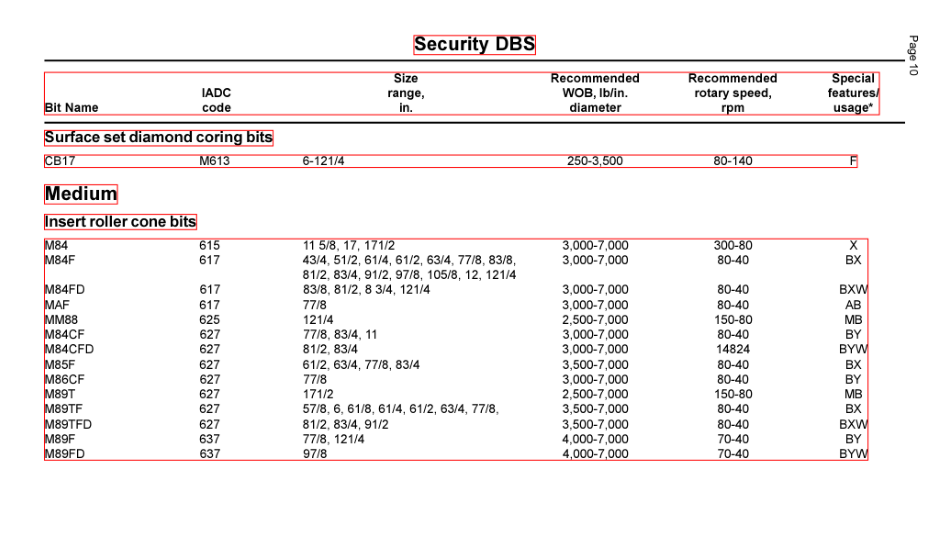

In [43]:
sample_df1 = extract_and_visualize_blocks(test_sample_1, page_number=0, dpi=150)

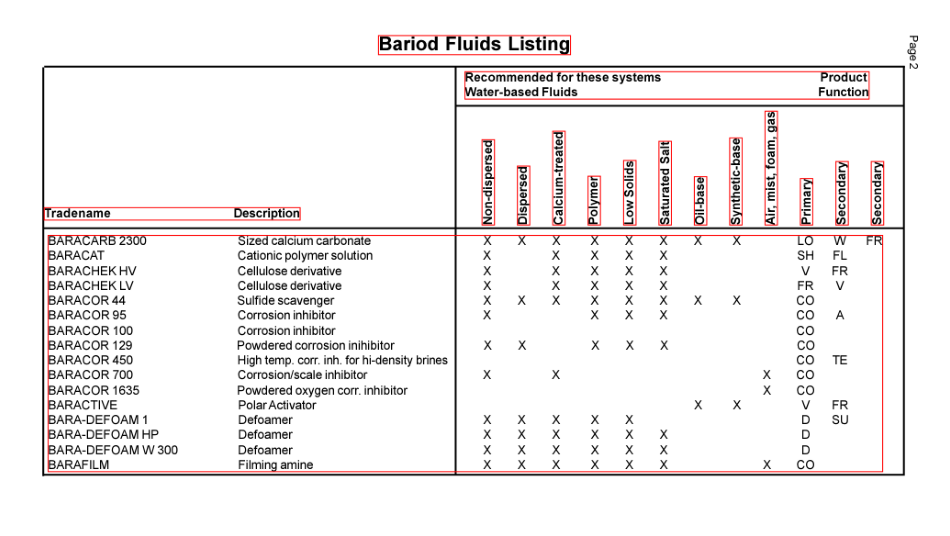

In [44]:
sample_df2 = extract_and_visualize_blocks(test_sample_2, page_number=0, dpi=150)

* Removing the blocks whose size is below the threshold
  * Check the size of the block with "Page _x_" and then, eliminate all the blocks which has the size less than this

In [45]:
sample_df1

,block_no,block_type,text,x0,y0,x1,y1,width,height,area
0,7,0,Security DBS,211.197006,13.869678,274.774902,23.869677,63.58,10.0,635.80
1,6,0,Size\nRecommended\nRecommended\nSpecial\nIADC\...,18.001045,33.173489,454.582123,55.273495,436.58,22.1,9648.42
2,1,0,Surface set diamond coring bits,18.010201,63.537025,137.561295,71.537025,119.55,8.0,956.40
3,2,0,"CB17\nM613\n6-121/4\n250-3,500\n80-140\nF",18.010201,76.346336,443.013367,82.846336,425.00,6.5,2762.50
4,3,0,Medium,18.011200,91.915588,56.201096,101.915588,38.19,10.0,381.90
5,4,0,Insert roller cone bits,18.011200,107.336235,97.604935,115.336235,79.59,8.0,636.72
6,5,0,"M84\n615\n11 5/8, 17, 171/2\n3,000-7,000\n300-...",18.011200,120.145546,448.616241,235.845566,430.61,115.7,49821.58


In [58]:
def show_page(page, dpi=150, figsize=(12, 16)):
    pix = page.get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png")))

    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


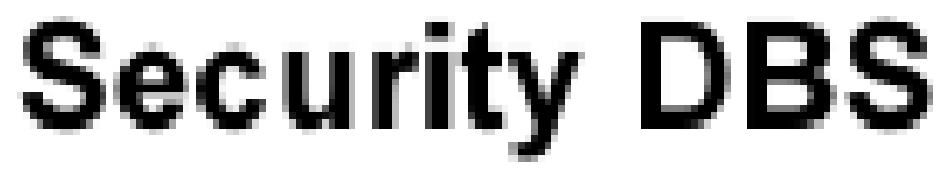

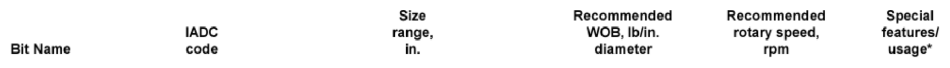

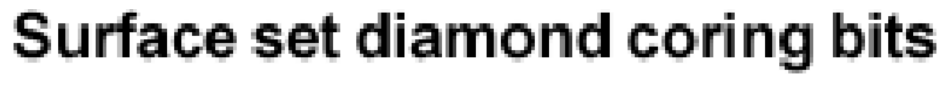

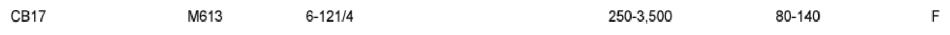

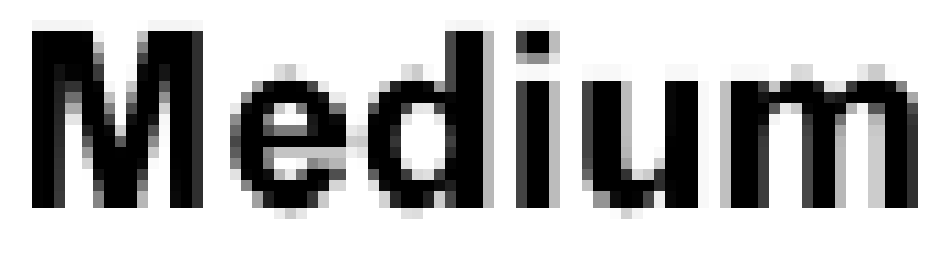

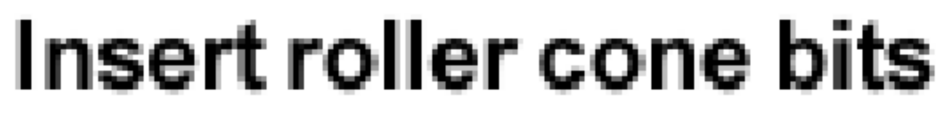

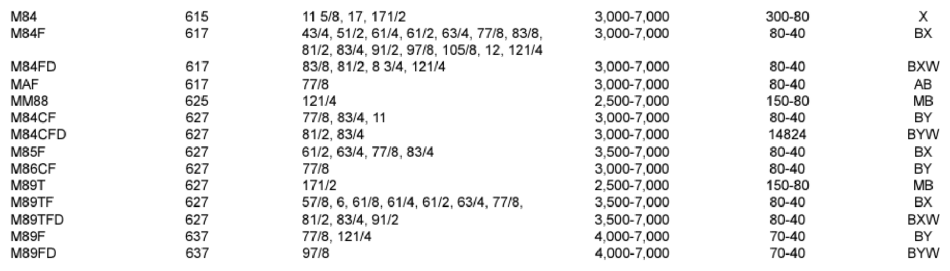

In [ ]:
for block in blocks1:
    x0, y0, x1, y1, text, block_no, block_type = block
    rect = fitz.Rect(x0, y0, x1, y1)
    
    width = round(x1 - x0, 2)
    height = round(y1 - y0, 2)
    area = round(width * height, 2)

    if area < 130:
        continue
    
    # only the text inside this rectangular region
    pix = page1.get_pixmap(dpi=150, clip=rect)
    
    new_doc = fitz.open()
    rect_size = fitz.Rect(0, 0, pix.width, pix.height)
    new_page = new_doc.new_page(width=rect_size.width, height=rect_size.height)

    img = pix.tobytes("png")
    new_page.insert_image(rect_size, stream=img)

    show_page(new_page)

    

### Proceeding

In [107]:
pg_dict1 = page1.get_text("dict", sort=True)

print(pg_dict1.keys())

dict_keys(['width', 'height', 'blocks'])


In [ ]:
def annotate_words_safe(pdf_path, page_number=0, dpi=150):
    """
    Draw bounding boxes around all words on a PDF page and display the annotated result.
    Uses get_text("words") for compatibility and safety.
    """
    
    # temporary clone
    original_doc = fitz.open(pdf_path)
    temp_doc = fitz.open()
    temp_doc.insert_pdf(original_doc, from_page=page_number, to_page=page_number)
    page = temp_doc[0]

    word_data = []

    # Extract all words (x0, y0, x1, y1, "text", block_no, line_no, word_no)
    words = page.get_text("words")

    for word in words:
        x0, y0, x1, y1, text = word[:5]
        rect = fitz.Rect(x0, y0, x1, y1)
        page.draw_rect(rect, color=(0, 0, 1), width=0.3)  # Blue box
        word_data.append((text, rect))

    pix = page.get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png")))

    plt.figure(figsize=(12, 16))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    original_doc.close()
    temp_doc.close()

    return word_data


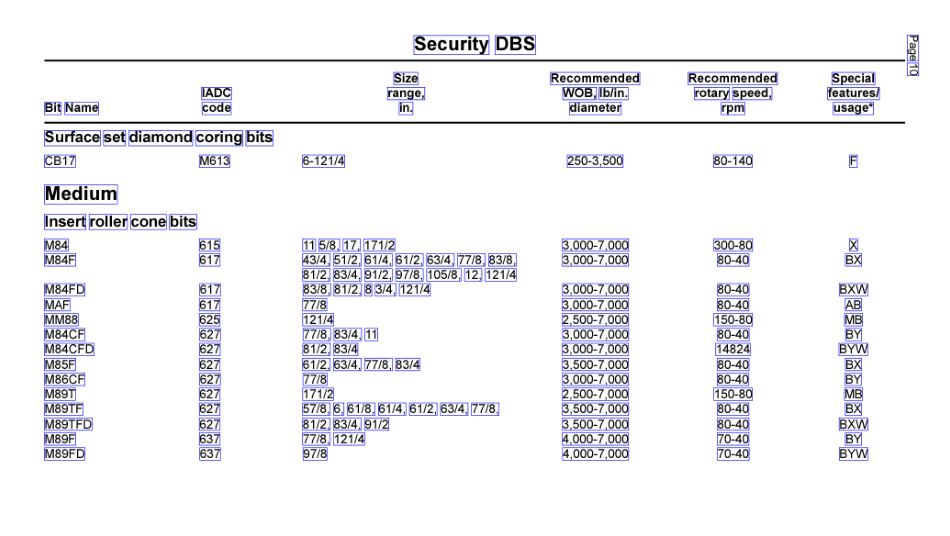

In [ ]:
word_info_1 = annotate_words_safe(test_sample_1, page_number=0)

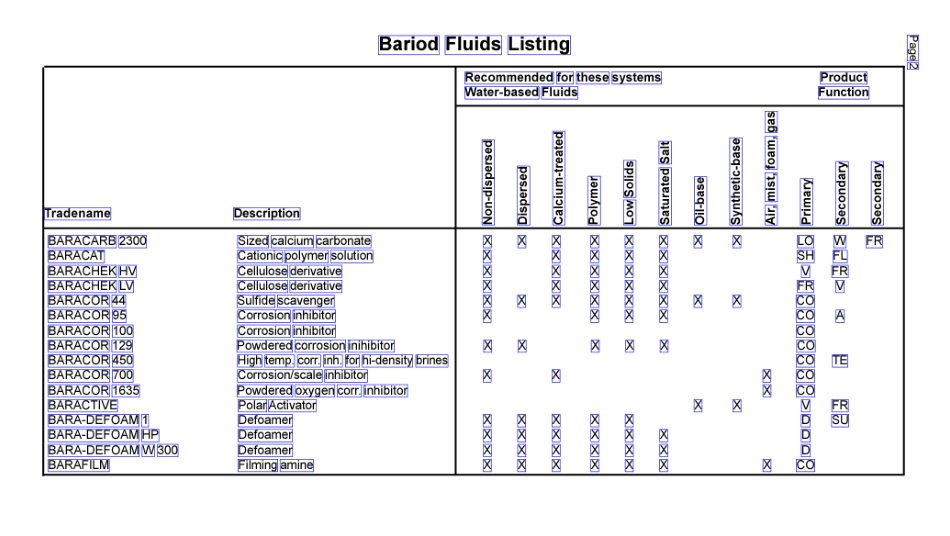

In [115]:
word_info_2 = annotate_words_safe(test_sample_2, page_number=0)

In [222]:
def extract_blocks_and_words(pdf_path, page_number=0, dpi=150, block_area_thresh=130, save_as_pdf=True, output_pdf_path="./output/page1.pdf"):
    doc = fitz.open(pdf_path)
    temp_doc = fitz.open()
    temp_doc.insert_pdf(doc, from_page=page_number, to_page=page_number)
    page = temp_doc[0]

    # ==========================
    # 1. BLOCK-LEVEL PROCESSING
    # ==========================
    blocks = page.get_text("blocks", sort=True)
    kept_blocks = []
    block_data = []

    for block in blocks:
        x0, y0, x1, y1, text, block_no, block_type = block
        width = round(x1 - x0, 2)
        height = round(y1 - y0, 2)
        area = round(width * height, 2)

        if area < block_area_thresh:
            continue

        rect = fitz.Rect(x0, y0, x1, y1)
        page.draw_rect(rect, color=(1, 0, 0), width=0.5)  # Red block outline

        kept_blocks.append(rect)
        block_data.append([
            block_no, block_type, text.strip(),
            x0, y0, x1, y1, width, height, area
        ])

    df_blocks = pd.DataFrame(block_data, columns=[
        'block_no', 'block_type', 'text', 'x0', 'y0', 'x1', 'y1',
        'width', 'height', 'area'
    ])

    # ========================
    # 2. FILTERED WORD DRAWING
    # ========================
    words = page.get_text("words")
    word_data = []

    for word in words:
        x0, y0, x1, y1, text = word[:5]
        word_rect = fitz.Rect(x0, y0, x1, y1)

        # Check if word lies within any kept block
        if any(block_rect.contains(word_rect) for block_rect in kept_blocks):
            page.draw_rect(word_rect, color=(0, 0, 1), width=0.3)  # Blue word box
            word_data.append((text, word_rect))

    # ====================
    # 3. RENDER & DISPLAY
    # ====================
    pix = page.get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png")))

    plt.figure(figsize=(12, 16))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # =========================
    # 4. SAVE AS PDF (if requested)
    # =========================
    if save_as_pdf:
        # Create a new PDF document
        new_doc = fitz.open()

        # Create a new page with the same dimensions as the rendered image
        rect_size = fitz.Rect(0, 0, pix.width, pix.height)
        new_page = new_doc.new_page(width=rect_size.width, height=rect_size.height)

        # Insert the image as a stream into the new page
        img_bytes = pix.tobytes("png")
        new_page.insert_image(rect_size, stream=img_bytes)

        # Save the new document to disk
        new_doc.save(output_pdf_path)


    # temp_doc.close()
    # doc.close()

    return df_blocks, word_data, page, blocks, img


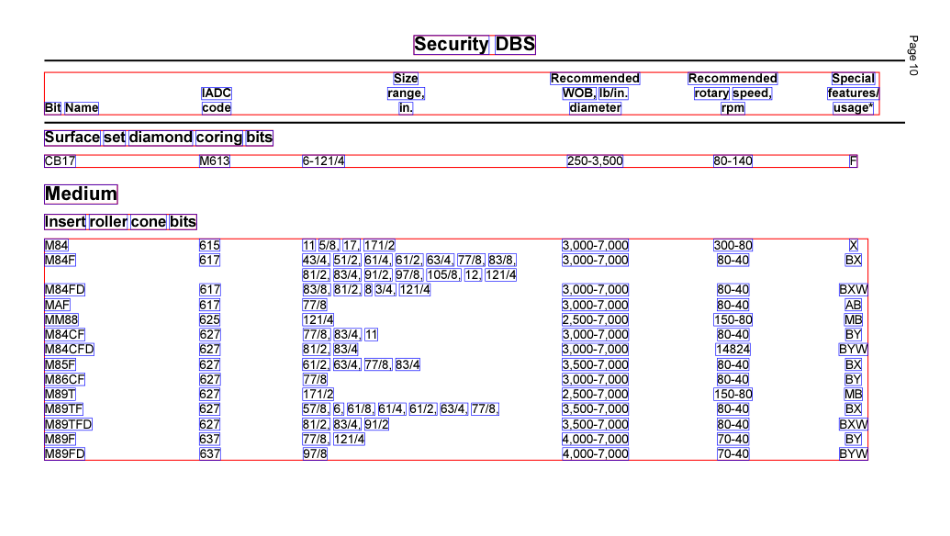

In [223]:
df_blocks_1, word_info_1, page_1, blocks_1, img_1 = extract_blocks_and_words(test_sample_1, page_number=0, output_pdf_path="./output/page_1.pdf")


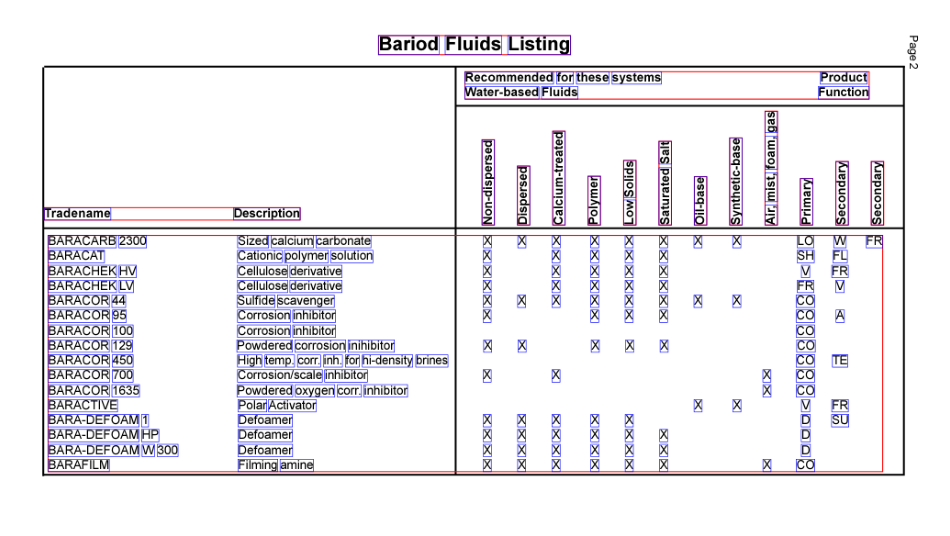

In [225]:
df_blocks_2, word_info_2, page_2, blocks_2, img_2 = extract_blocks_and_words(test_sample_2, page_number=0, output_pdf_path="./output/page_2.pdf")


### Checking

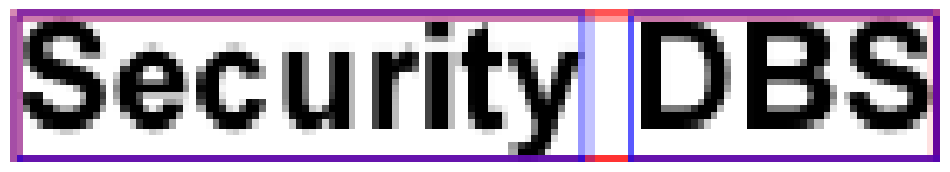

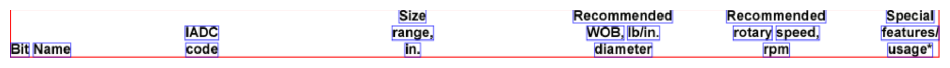

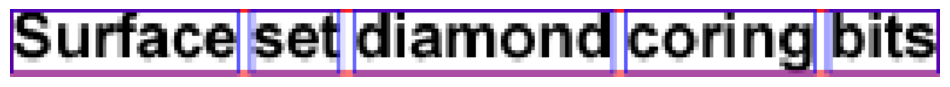

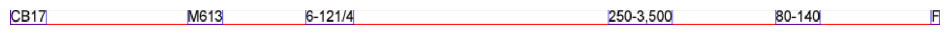

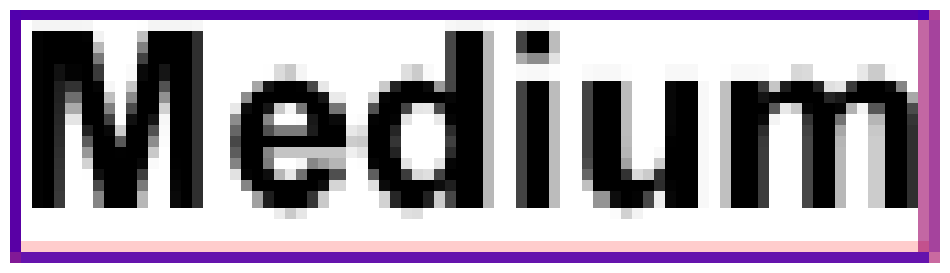

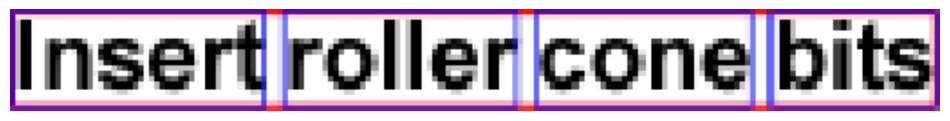

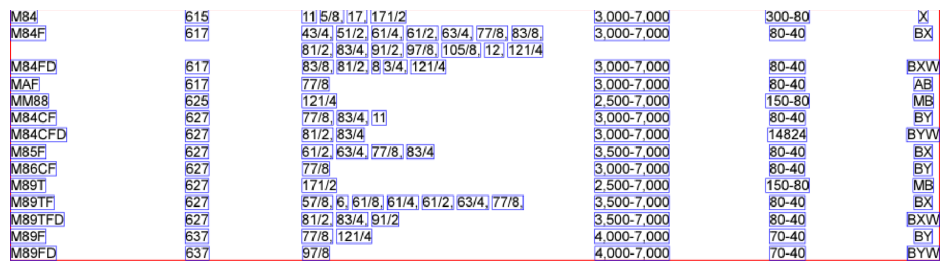

In [177]:
for block in blocks_1:
    x0, y0, x1, y1, text, block_no, block_type = block
    rect = fitz.Rect(x0, y0, x1, y1)
    
    width = round(x1 - x0, 2)
    height = round(y1 - y0, 2)
    area = round(width * height, 2)

    if area < 130:
        continue
    
    # only the text inside this rectangular region
    pix = page_1.get_pixmap(dpi=150, clip=rect)
    
    new_doc = fitz.open()
    rect_size = fitz.Rect(0, 0, pix.width, pix.height)
    new_page = new_doc.new_page(width=rect_size.width, height=rect_size.height)

    img = pix.tobytes("png")
    new_page.insert_image(rect_size, stream=img)

    show_page(new_page)

    

### Sample PDF 1

In [158]:
first_row = df_blocks_1.iloc[0].values[2]

print(first_row)

Security DBS


In [216]:

def extract_pdf_table_structure(pdf_path, page_number=0, dy_threshold=3, dx_threshold=5):
    doc = fitz.open(pdf_path)
    page = doc[page_number]
    words = page.get_text("words")  # (x0, y0, x1, y1, text, block_no, line_no, word_no)

    words.sort(key=lambda w: (round(w[1], 1), w[0]))  # Sort by y, then x

    # === Group words into rows ===
    grouped_rows = []
    current_row = []
    current_y = None

    for w in words:
        x0, y0, x1, y1, text = w[:5]
        if current_y is None or abs(y0 - current_y) < dy_threshold:
            current_row.append((x0, y0, x1, y1, text))
            current_y = y0 if current_y is None else min(current_y, y0)
        else:
            grouped_rows.append(current_row)
            current_row = [(x0, y0, x1, y1, text)]
            current_y = y0
    if current_row:
        grouped_rows.append(current_row)

    # === Extract header lines ===
    header_cells = defaultdict(str)
    data_start_index = 0
    header_found = False

    for i, row in enumerate(grouped_rows[:6]):  # first few rows may be header
        row_text = " ".join([t[-1] for t in row])
        if any(h in row_text for h in ["Bit", "IADC", "Size", "Recommended"]):
            for x0, y0, x1, y1, word in row:
                mid_x = (x0 + x1) / 2
                header_cells[mid_x] += word + " "
            header_found = True
        elif header_found:
            data_start_index = i
            break

    if not header_cells:
        raise ValueError("No header found. Please check the dy_threshold or the document layout.")

    header_keys = [header_cells[k].strip() for k in sorted(header_cells)]
    header_xs = sorted(header_cells)

    # === Parse data ===
    data = []
    current_section = None
    for row in grouped_rows[data_start_index:]:
        row_text = " ".join([t[-1] for t in row])
        
        # Section titles like "Medium"
        if len(row) <= 2 and len(row_text.split()) <= 3:
            current_section = row_text
            continue

        row_dict = {}
        cells = sorted(row, key=lambda x: x[0])
        column_cells = [[] for _ in header_keys]

        for x0, y0, x1, y1, word in cells:
            mid_x = (x0 + x1) / 2
            if not header_xs:
                continue  # no headers to map
            distances = [abs(mid_x - hx) for hx in header_xs]
            if distances:
                min_index = int(np.argmin(distances))
                column_cells[min_index].append(word)

        for idx, col_words in enumerate(column_cells):
            row_dict[header_keys[idx]] = " ".join(col_words)

        row_dict["Section"] = current_section
        data.append(row_dict)

    df = pd.DataFrame(data)
    return df

In [217]:
df = extract_pdf_table_structure(test_sample_1, page_number=0)


In [218]:
df

,Bit,Name,IADC,code,Size,in.,"range,","WOB,",Recommended,diameter,lb/in.,rotary,rpm,"speed,",Special,usage*,features/,Section
0,,Surface set,diamond,coring bits,,,,,,,,,,,,,,None
1,CB17,,M613,,6-121/4,,,,,,,,80-140,,,,F,None
2,Insert,roller cone,bits,,,,,,,,,,,,,,,Medium
3,M84,,615,11,"5/8, 17, 171/2",,,,,"3,000-7,000",,,300-80,,,,X,Medium
4,M84F,,617,,"43/4, 51/2, 61/4,",,"61/2, 63/4, 77/8,","83/8,",,"3,000-7,000",,,80-40,,,BX,,Medium
5,,,,,"81/2, 83/4, 91/2,",,"97/8, 105/8, 12,",121/4,,,,,,,,,,Medium
6,M84FD,,617,,"83/8, 81/2, 8 3/4,",,121/4,,,"3,000-7,000",,,80-40,,,,BXW,Medium
7,MAF,,617,,77/8,,,,,"3,000-7,000",,,80-40,,AB,,,Medium
8,MM88,,625,,121/4,,,,,"2,500-7,000",,,150-80,,,,MB,Medium
9,M84CF,,627,,"77/8, 83/4, 11",,,,,"3,000-7,000",,,80-40,,,,BY,Medium


### Llava

In [ ]:

def encode_pil_image_to_base64(pil_image):
    """Encodes a PIL Image object to a base64 string."""
    buffered = BytesIO()
    pil_image.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str

In [168]:
type(img_1)

PIL.PngImagePlugin.PngImageFile

In [170]:
base64_image = encode_pil_image_to_base64(img_1)


In [ ]:

if base64_image:
    client = ollama.Client()

    messages = [
        {
            'role': 'user',
            'content': f'Extract the data from this table and present it as a CSV.  <image>{base64_image}</image>',
            'images': [base64_image],
        },
    ]

    try:
        response = client.chat(
            model='llava:latest',
            messages=messages,
        )

        extracted_text = response['message']['content']
        print("Raw extracted text:")
        print(extracted_text)

        try:
            from io import StringIO
            csv_data = StringIO(extracted_text)
            df = pd.read_csv(csv_data)
            print("\nExtracted Table (Pandas DataFrame):")
            print(df)
        except Exception as e:
            print("\nCould not directly parse as CSV. Further processing might be needed.")
            print(f"Error: {e}")
    except Exception as e:
        print(f"Error during Ollama chat: {e}")


Error during Ollama chat: an unknown error was encountered while running the model  (status code: 500)


In [175]:
df

,The content of your request could not be found.
